# Diabetes Challenge

Your task today is to **analyze** the Kaggle "Pima Indians Diabetes Database" and to **predict** whether a patient has Diabetes or not.

## Task:
- Load the data from the database. The schema is called `diabetes`. To connect to the database you need to copy the `.env` file from the visualization or hands-on-ml repository into this repo. Explore the database, try to establish what the relationships between the tables are (1-1, 1-N, N-M). Explain to yourself and the group what data do you see and whether it makes sense. What JOINs are appropriate to use and why? 
- Use at least two different classification algorithms we have learned so far to predict Diabetes patients. 
- Discuss before you start with the modeling process which **evaluation metric** you choose and explain why.
- Implement a GridSearchCV or RandomizedSearchCV to tune the hyperparameters of your model.
- **Optional:** If you have time at the end, try to use sklearn's pipline module to encapsulate all the steps into a pipeline.

Don't forget to split your data in train and test set. And analyze your final model on the test data. It might also be necessary to scale your data in order to improve the performance of some of the models.


## Helpful links and advise:
- [sklearn documentation on hyperparameter tuning](https://scikit-learn.org/stable/modules/grid_search.html#grid-search)
- It might be helpful to check some sources on how to deal with imbalanced data. 
    * [8 Tactics to Combat Imbalanced Classes](https://machinelearningmastery.com/tactics-to-combat-imbalanced-classes-in-your-machine-learning-dataset/)
    * [Random-Oversampling/Undersampling](https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/)


# Data Description

## Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

## Acknowledgements
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.

## About this dataset
The datasets consist of several medical predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on. For the outcome class value 1 is interpreted as "tested positive for diabetes".

|Column Name| Description|
|:------------|:------------|
|Pregnancies|Number of times pregnant|
|Glucose|Plasma glucose concentration a 2 hours in an oral glucose tolerance test|
|BloodPressure|Diastolic blood pressure (mm Hg)|
|SkinThickness|Triceps skin fold thickness (mm)|
|Insulin|2-Hour serum insulin (mu U/ml)|
|BMI|Body mass index (weight in kg/(height in m)^2)|
|DiabetesPedigreeFunction| Diabetes pedigree function|
|Age| Age (years)|
|Outcome|Class variable (0 or 1) |

In [35]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

import numpy as np
import pandas as pd

from scipy.stats import skew
from scipy import stats
from scipy.stats import norm
from timeit import default_timer as timer


# Modelling

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import loguniform
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    KBinsDiscretizer,
    PolynomialFeatures
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Plot
import matplotlib.pyplot as plt
import seaborn as sns
#import plotly.express as px
from matplotlib.ticker import PercentFormatter
plt.rcParams.update({ "figure.figsize" : (8, 5),"axes.facecolor" : "white", "axes.edgecolor":  "black"})
plt.rcParams["figure.facecolor"]= "w"
pd.plotting.register_matplotlib_converters()
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.options.display.float_format = "{:,.2f}".format
import warnings
warnings.filterwarnings('ignore')

RSEED = 42


# Feel free to add all the libraries you need


In [2]:
# Read database string from .env file (no need to change anything)
load_dotenv()

DB_STRING = os.getenv('DB_STRING')

db = create_engine(DB_STRING)

In [3]:
# Define query to download data (add your query here)
query_string = ''' 
set SCHEMA 'diabetes';
SELECT p.id as patient_id, p."Age", p.pregnancies, p.bmi, 
sk.skinthickness,
ped.diabetespedigreefunction, ped.outcome, 
bld.insulin, bld.glucose, bld.bloodpressure, bld.measurement_date
FROM patient p
LEFT JOIN skin sk
ON p.id = sk.patientid
LEFT JOIN pedigree_outcome ped
ON p.id = ped.patientid
LEFT JOIN blood_metrics bld
ON p.id = bld.patientid
ORDER BY p.id ASC;
'''
# Import with pandas
df_sqlalchemy = pd.read_sql(query_string, db)
df_sqlalchemy.head()

,patient_id,Age,pregnancies,bmi,skinthickness,diabetespedigreefunction,outcome,insulin,glucose,bloodpressure,measurement_date
0,1,50,6,33.60,35,0.63,1,80,172,117,2022-12-01
1,1,50,6,33.60,35,0.63,1,0,148,72,2022-12-13
2,2,31,1,26.60,29,0.35,0,80,54,93,2022-12-01
3,2,31,1,26.60,29,0.35,0,0,85,66,2022-12-13
4,3,32,8,23.30,0,0.67,1,0,183,64,2022-12-13


In [4]:
if not os.path.exists("./data"):
    os.mkdir("data")

In [5]:
# Save dataframe as .csv file
df_sqlalchemy.to_csv("data/heart_data.csv", index=False)

In [6]:
df = pd.read_csv("data/heart_data.csv", parse_dates=["measurement_date"])

In [7]:
df.isna().sum()

patient_id                  0
Age                         0
pregnancies                 0
bmi                         0
skinthickness               0
diabetespedigreefunction    0
outcome                     0
insulin                     0
glucose                     0
bloodpressure               0
measurement_date            0
dtype: int64

In [8]:
df.rename(columns={"diabetespedigreefunction": "diabet_ped_func"}, inplace=True)

In [9]:
df.info() #When looking at feature description and type of columns, it seems there is no mismatch with data type.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   patient_id        1536 non-null   int64         
 1   Age               1536 non-null   int64         
 2   pregnancies       1536 non-null   int64         
 3   bmi               1536 non-null   float64       
 4   skinthickness     1536 non-null   int64         
 5   diabet_ped_func   1536 non-null   float64       
 6   outcome           1536 non-null   int64         
 7   insulin           1536 non-null   int64         
 8   glucose           1536 non-null   int64         
 9   bloodpressure     1536 non-null   int64         
 10  measurement_date  1536 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(8)
memory usage: 132.1 KB


In [10]:
#We found out that there are only 2 dates in the data and ddata entries in one date is 
#fake, so we drop data on that date
df = df[df['measurement_date'] != '2022-12-01']
df.drop(columns=['measurement_date'], axis=1, inplace=True) 

## Train-Test Split

In [11]:
y=df[['outcome']]
X=df.drop(columns=['outcome'], axis=1)

In [12]:
print(f'shape of X: {X.shape}')
print(f'shape of y: {y.shape}')

shape of X: (768, 9)
shape of y: (768, 1)


In [13]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, random_state=42)

In [14]:
print(f'shape of X_train: {X_train.shape}')
print(f'shape of y_train: {y_train.shape}')
print(f'shape of X_test: {X_test.shape}')
print(f'shape of y_test: {y_test.shape}')

shape of X_train: (576, 9)
shape of y_train: (576, 1)
shape of X_test: (192, 9)
shape of y_test: (192, 1)


## EDA

In [15]:
df_train=pd.concat([X_train, y_train], axis=1)

In [16]:
df_train.head()

,patient_id,Age,pregnancies,bmi,skinthickness,diabet_ped_func,insulin,glucose,bloodpressure,outcome
715,358,44,13,39.90,30,0.57,0,129,0,1
147,74,23,4,35.10,20,0.23,270,129,86,0
704,353,46,3,34.40,28,0.24,0,61,82,0
994,498,25,2,30.10,15,0.55,76,81,72,0
291,146,21,0,0.00,23,0.57,0,102,75,0


In [17]:
df_train.columns

Index(['patient_id', 'Age', 'pregnancies', 'bmi', 'skinthickness',
       'diabet_ped_func', 'insulin', 'glucose', 'bloodpressure', 'outcome'],
      dtype='object')

In [18]:
features=df_train[['Age', 'pregnancies', 'bmi', 'skinthickness','diabet_ped_func', 'insulin',
       'glucose' , 'bloodpressure', 'outcome']]

In [19]:
df_train['patient_id'].duplicated().sum() 

0

In [20]:
features.describe()

,Age,pregnancies,bmi,skinthickness,diabet_ped_func,insulin,glucose,bloodpressure,outcome
count,576.00,576.00,576.00,576.00,576.00,576.00,576.00,576.00,576.00
mean,32.92,3.74,31.98,20.49,0.47,80.36,120.66,69.51,0.35
std,11.51,3.31,7.62,15.42,0.34,116.22,32.13,18.40,0.48
min,21.00,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.00
25%,24.00,1.00,27.00,0.00,0.24,0.00,99.00,64.00,0.00
50%,29.00,3.00,32.00,23.00,0.37,37.00,117.00,72.00,0.00
75%,40.00,6.00,36.32,32.00,0.61,127.50,138.25,80.00,1.00
max,81.00,17.00,67.10,63.00,2.42,846.00,199.00,122.00,1.00


In [21]:
df_train.loc[df['pregnancies']==17]

,patient_id,Age,pregnancies,bmi,skinthickness,diabet_ped_func,insulin,glucose,bloodpressure,outcome
319,160,47,17,40.90,41,0.82,114,163,72,1


KeyError: 'measurement_date'

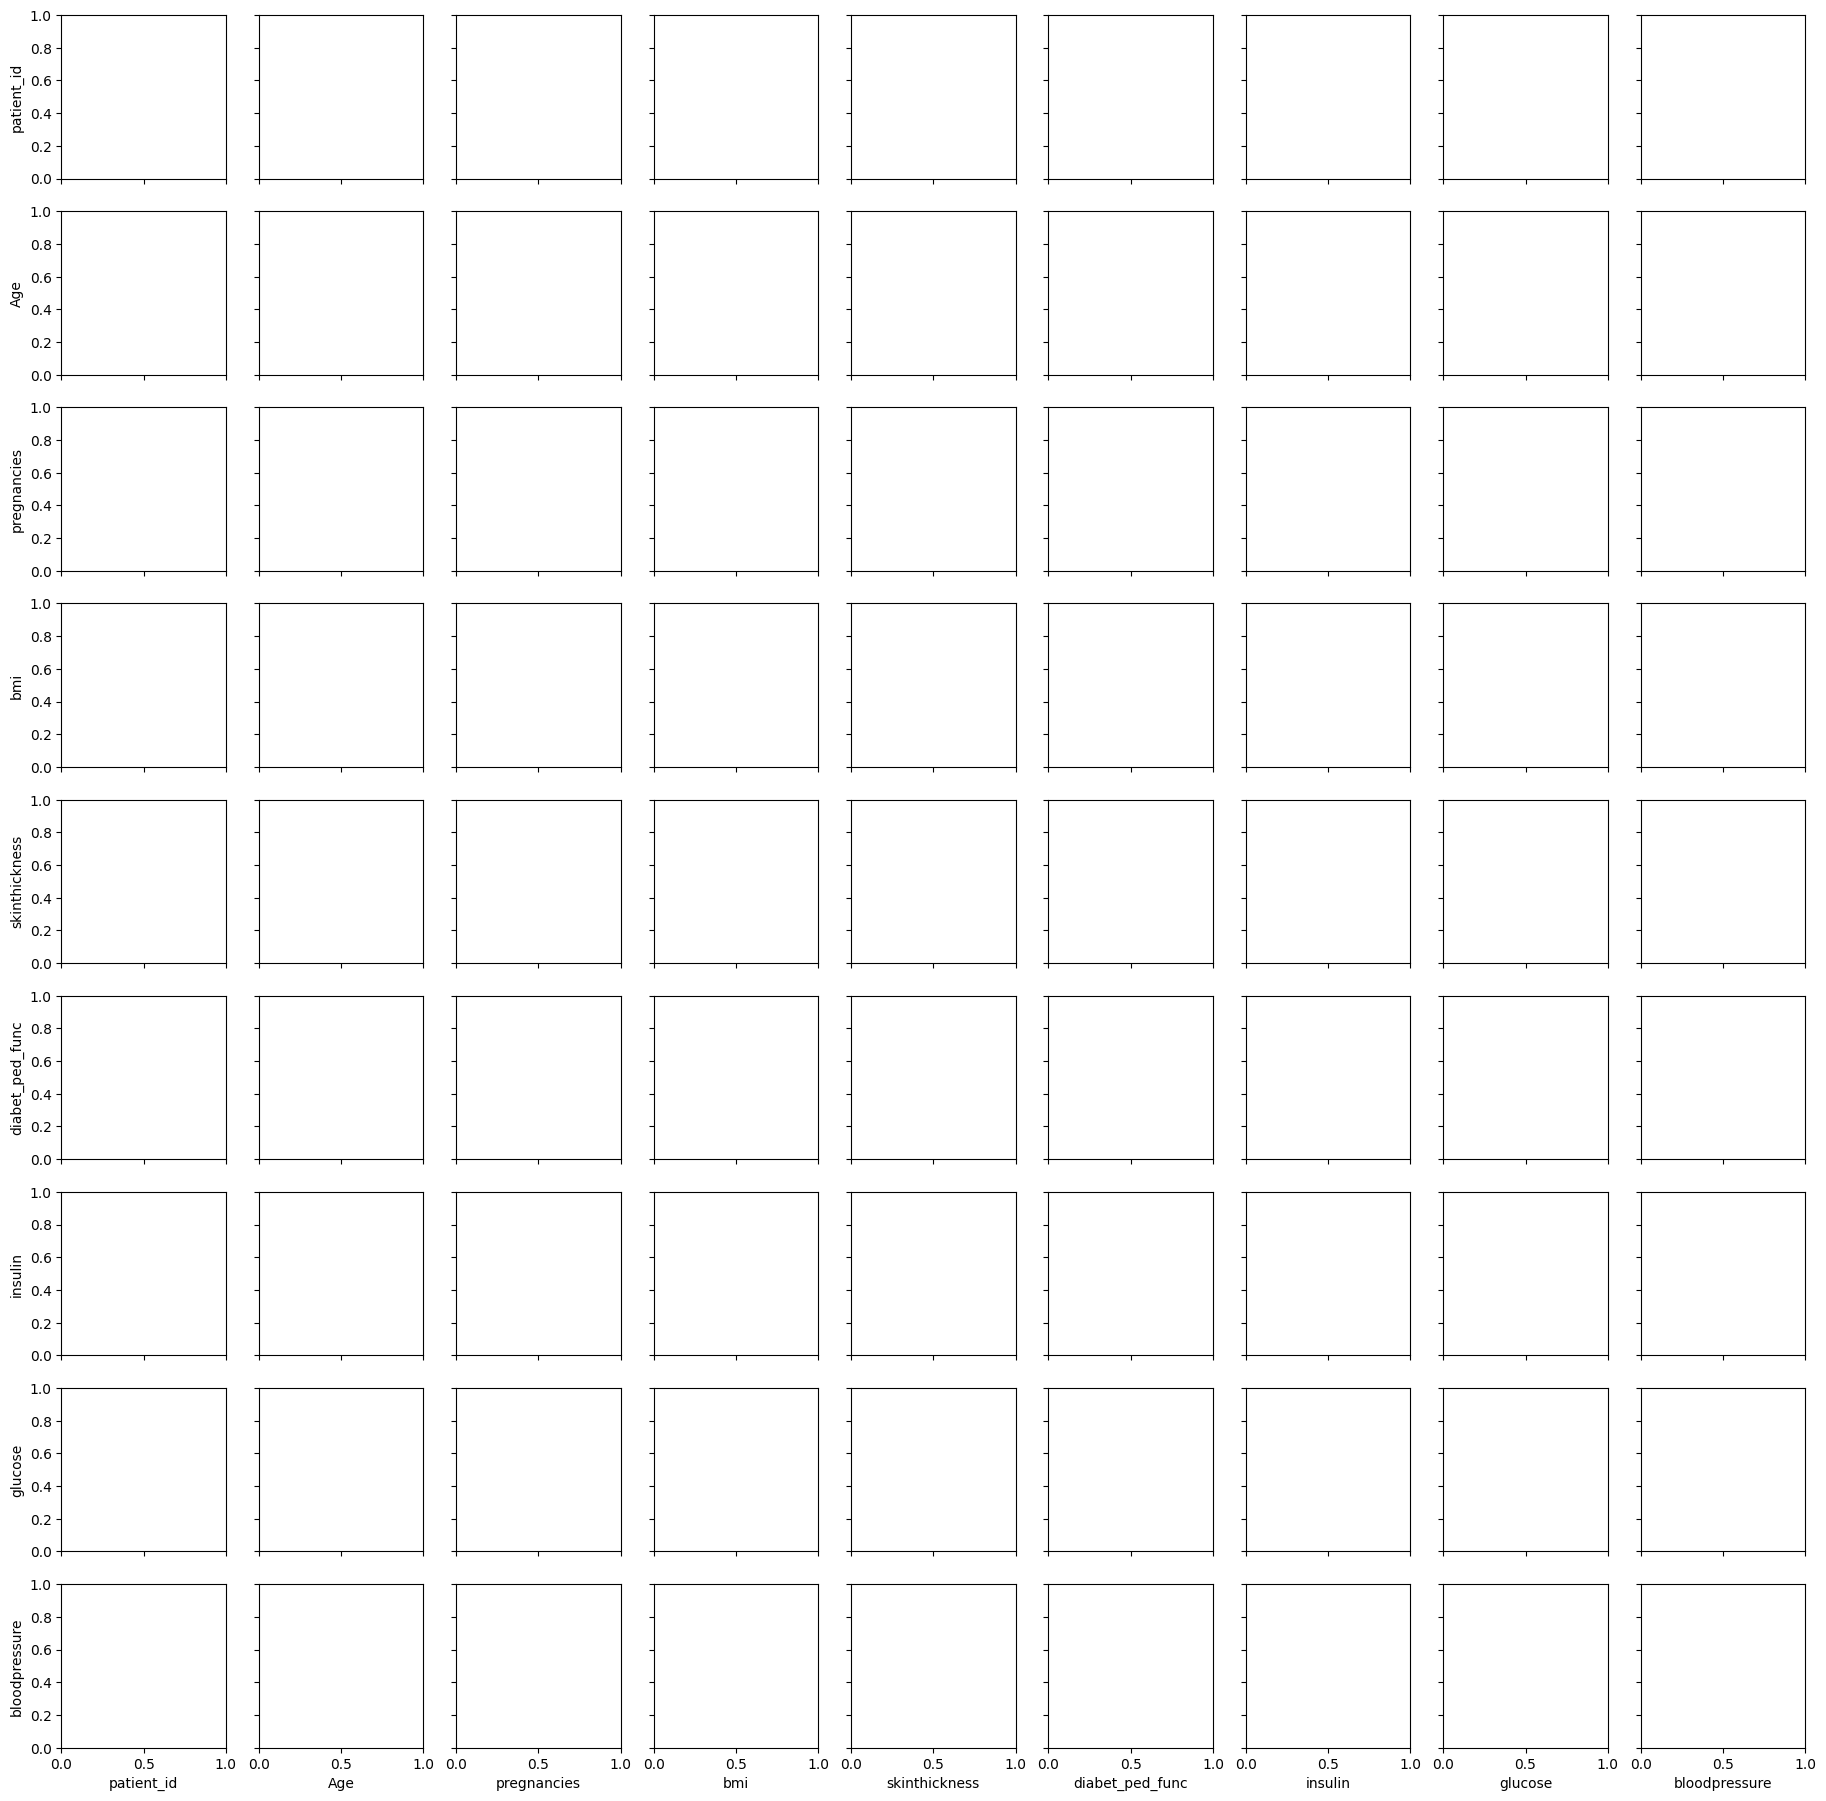

In [22]:
sns.pairplot(X_train, hue='measurement_date') #date December 1st has unrealistic, fake  data, we dropped at the beginning it

In [ ]:
sns.pairplot(features, hue='outcome')

In [ ]:
#show % of outcomes
import seaborn as sns
import matplotlib.pyplot as plt

perc = y['outcome'].value_counts(normalize=True).reset_index()
perc.columns = ['outcome', 'percentage']
perc['percentage'] *= 100

ax = sns.barplot(data=perc, x='outcome', y='percentage')

# percentage labels on bars
for i, row in perc.iterrows():
    ax.text(
        i,
        row['percentage'],
        f"{row['percentage']:.1f}%",
        ha='center',
        va='bottom'
    )

# clean up axes
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# force x tick labels from data
ax.set_xticks(range(len(perc)))
ax.set_xticklabels(perc['outcome'].astype(str))
plt.ylim(0, 100)
plt.title('Percentage of Patient with Diabetes')
plt.show()

In [ ]:
import seaborn as sns
# compute correlation matrix
corr_matrix =features.corr()

# plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
features.columns


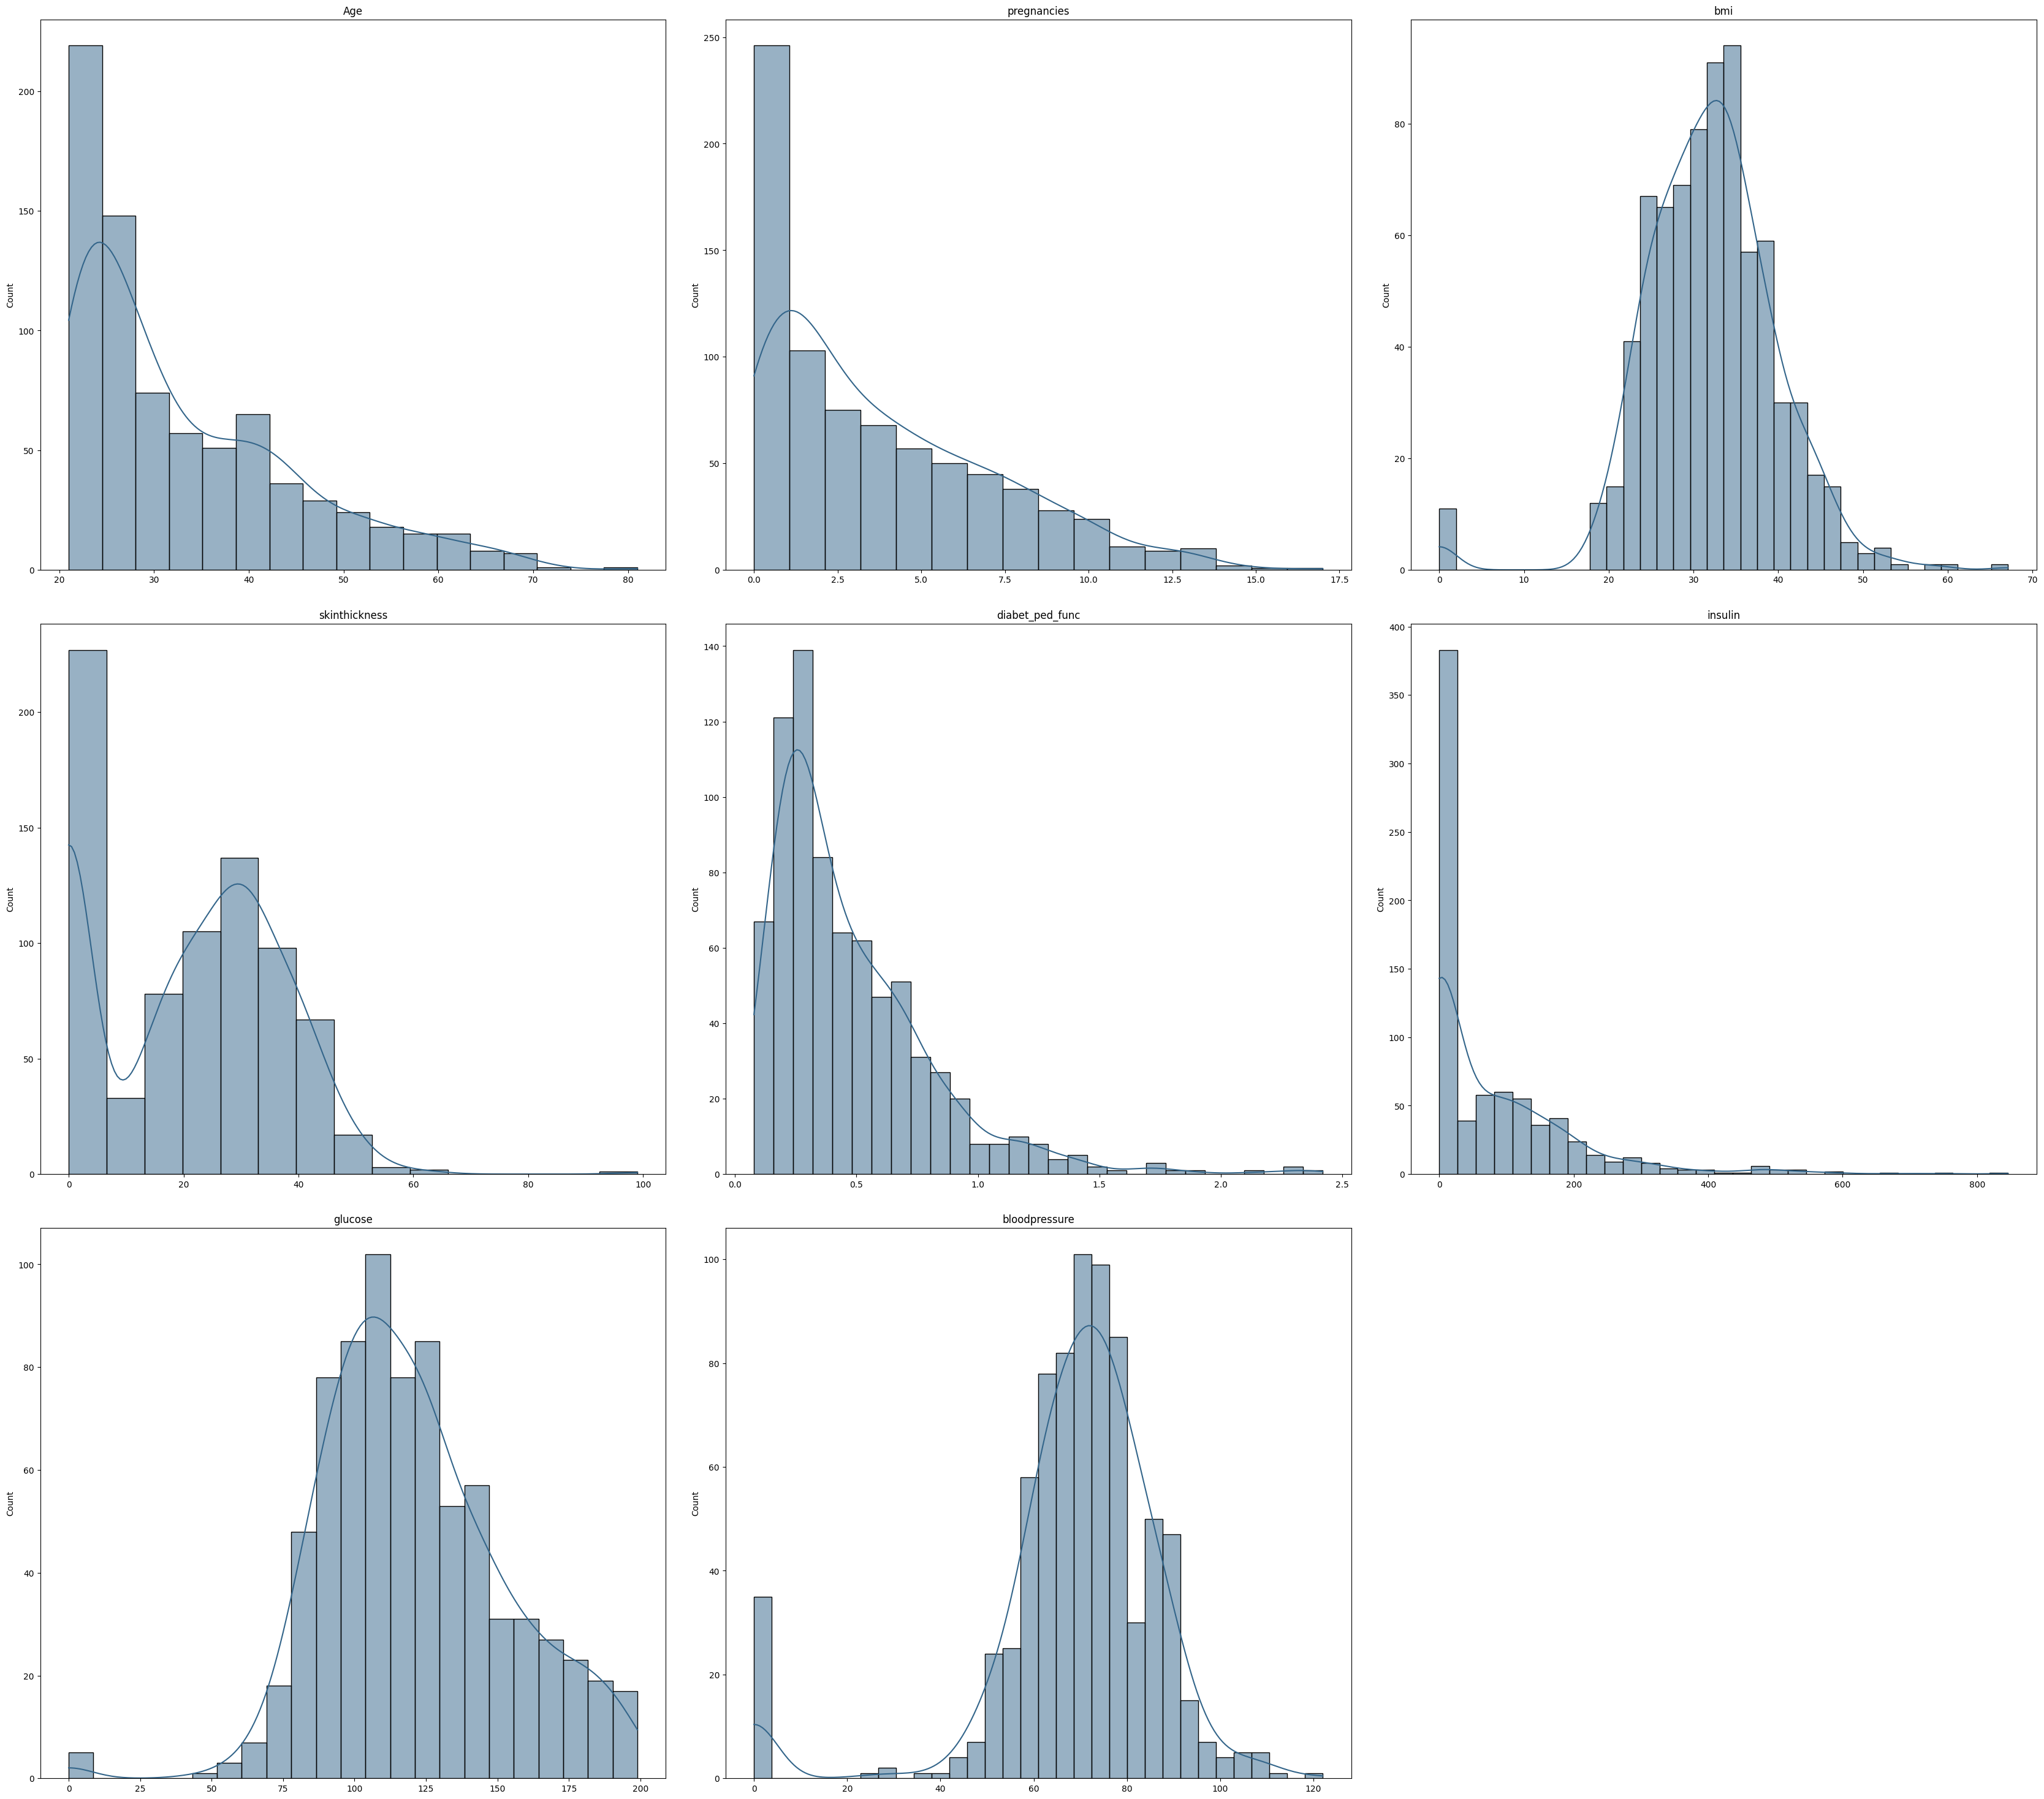

In [23]:
# Plot distribution of features 
features1=features.columns

fig,ax = plt.subplots(3,3,figsize=(34,30))
count = 0
for item in features1:
    sns.histplot(df[item], kde=True, ax=ax[int(count/3)][count%3], color='#33658A').set(title=item, xlabel='')
    count += 1
ax.flat[-1].set_visible(False)
fig.tight_layout(pad=3)

Skin tickness and bloodpressure have less than 0.10 correlation, so it seems that would not contribute to the performance of our model.

## Pipeline for feature engineering and logistic regression

In [26]:

num_features=X_train.columns
col_scaler=ColumnTransformer(transformers=[
        ("scaler", RobustScaler(), num_features)]        
).set_output(transform='pandas')

X_train=col_scaler.fit_transform(X_train)


In [ ]:
# Logistic Regression without the id field
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_train = log_reg.predict(X_train)
y_pred = log_reg.predict(X_test)

In [40]:
log_reg=LogisticRegression(class_weight='balanced', max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [41]:
from sklearn.model_selection import cross_val_predict
# Making predictions on the training set using cross validation as well as calculating the probabilities
# cross_val_predict expects an estimator (model), X, y and nr of cv-splits (cv)
y_train_pred= cross_val_predict(log_reg, X_train, y_train, cv=5)

In [42]:
# Calculating the accuracy for the LogisticRegression Classifier 
print('Cross validation scores:')
print('-------------------------')
print("Accuracy: {:.2f}".format(accuracy_score(y_train, y_train_pred)))
print("Recall: {:.2f}".format(recall_score(y_train, y_train_pred)))
print("Precision: {:.2f}".format(precision_score(y_train, y_train_pred)))

Cross validation scores:
-------------------------
Accuracy: 0.76
Recall: 0.73
Precision: 0.63


In [48]:
#Grid Search
# Defining parameter space for grid-search. Since we want to access the classifier step (called 'logreg') in our pipeline 
# we have to add 'logreg__' in front of the corresponding hyperparameters. 
param_logreg = [
    {"penalty": ["l1"], "C": [0.001, 0.01, 0.1, 1, 10], "solver": ["liblinear"]},
    {"penalty": ["l2"], "C": [0.001, 0.01, 0.1, 1, 10], "solver": ["liblinear", "lbfgs", "sag"]},
]

grid_logreg = GridSearchCV(
    log_reg,
    param_grid=param_logreg,
    cv=5,
    scoring="accuracy",
    verbose=5,
    n_jobs=-1
)


In [50]:
grid_logreg.fit(X_train, y_train.values.ravel())

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             n_jobs=-1,
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l1'],
                          'solver': ['liblinear']},
                         {'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l2'],
                          'solver': ['liblinear', 'lbfgs', 'sag']}],
             scoring='accuracy', verbose=5)

In [51]:
# Show best parameters
print('Best score:\n{:.2f}'.format(grid_logreg.best_score_))
print("Best parameters:\n{}".format(grid_logreg.best_params_))

Best score:
0.76
Best parameters:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [52]:
# Save best model (including fitted preprocessing steps) as best_model 
best_model = grid_logreg.best_estimator_
best_model

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000)

In [54]:
X_test=col_scaler.fit_transform(X_test)

In [55]:
#Test data
# Calculating the accuracy, recall and precision for the test set with the optimized model
y_test_predicted = best_model.predict(X_test)

print("Accuracy: {:.2f}".format(accuracy_score(y_test, y_test_predicted)))
print("Recall: {:.2f}".format(recall_score(y_test, y_test_predicted)))
print("Precision: {:.2f}".format(precision_score(y_test, y_test_predicted)))

Accuracy: 0.69
Recall: 0.68
Precision: 0.55
